In [10]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler

c:\Users\malle\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# ============================================
# 1. Download and Load Dataset
# ============================================

print("Downloading dataset...")

path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Dataset downloaded to:")
print(path)

print("\nFiles in dataset folder:")
print(os.listdir(path))

# Load CSV file
csv_path = os.path.join(path, "Titanic-Dataset.csv")
df = pd.read_csv(csv_path)


100%|██████████| 22.0k/22.0k [00:00<00:00, 195kB/s]

Extracting files...
Dataset downloaded to:
C:\Users\malle\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1

Files in dataset folder:
['Titanic-Dataset.csv']


In [12]:
# ============================================
# 2. Explore Dataset
# ============================================

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())



First 5 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

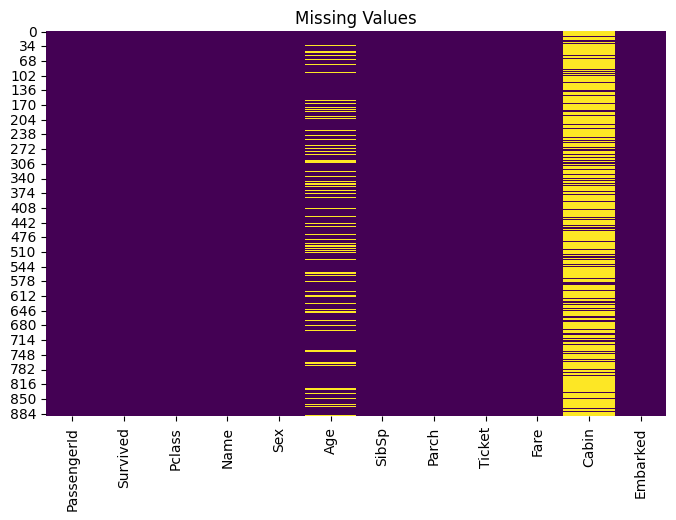

In [13]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values")
plt.savefig("missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# ============================================
# 3. Handle Missing Values
# ============================================

# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin because it has many missing values
df.drop("Cabin", axis=1, inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())




Missing Values After Cleaning
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [15]:
# ============================================
# 4. Encode Categorical Variables
# ============================================

encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])
df["Embarked"] = encoder.fit_transform(df["Embarked"])

print("\nEncoded Columns Successfully.")




Encoded Columns Successfully.


In [16]:
# ============================================
# 5. Remove Unnecessary Columns
# ============================================

columns_to_drop = ["PassengerId", "Name", "Ticket"]

for col in columns_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

print("\nRemaining Columns")
print(df.columns)




Remaining Columns
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')


In [17]:
# ============================================
# 6. Standardize Numerical Features
# ============================================

scaler = StandardScaler()

numeric_columns = ["Age", "Fare"]

df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

print("\nFeature Scaling Completed.")




Feature Scaling Completed.


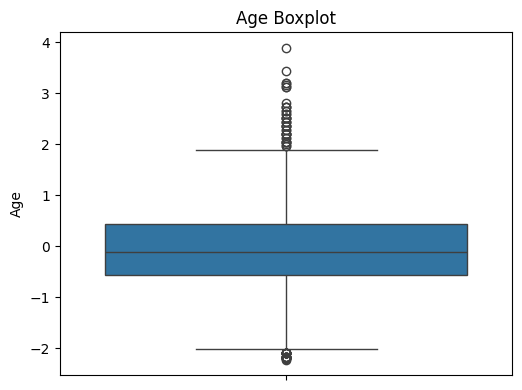

In [18]:
# ============================================
# 7. Visualize Outliers
# ============================================

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(y=df["Age"])
plt.title("Age Boxplot")


plt.tight_layout()
plt.show()



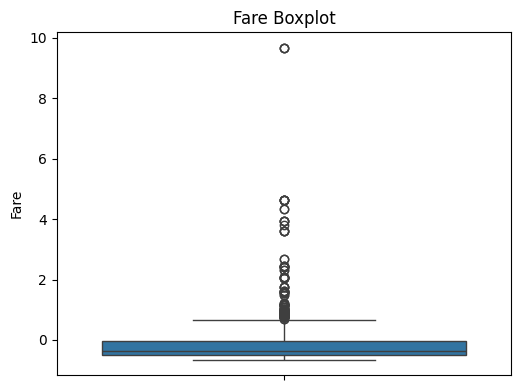

In [19]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,2)
sns.boxplot(y=df["Fare"])
plt.title("Fare Boxplot")

plt.tight_layout()
plt.show()

In [20]:
# ============================================
# 8. Remove Outliers using IQR (Fare)
# ============================================

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)]

print("\nShape After Removing Outliers")
print(df.shape)



Shape After Removing Outliers
(775, 8)


In [21]:
# ============================================
# 9. Save Cleaned Dataset
# ============================================

df.to_csv("Titanic_Cleaned.csv", index=False)

print("\nCleaned dataset saved as Titanic_Cleaned.csv")



Cleaned dataset saved as Titanic_Cleaned.csv


In [22]:
# ============================================
# 10. Final Preview
# ============================================

print("\nFinal Dataset")
print(df.head())

print("\nFinal Dataset Info")
print(df.info())

print("\nPreprocessing Completed Successfully!")


Final Dataset
   Survived  Pclass  Sex       Age  SibSp  Parch      Fare  Embarked
0         0       3    1 -0.565736      1      0 -0.502445         2
2         1       3    0 -0.258337      0      0 -0.488854         2
3         1       1    0  0.433312      1      0  0.420730         2
4         0       3    1  0.433312      0      0 -0.486337         2
5         0       3    1 -0.104637      0      0 -0.478116         1

Final Dataset Info
<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  775 non-null    int64  
 1   Pclass    775 non-null    int64  
 2   Sex       775 non-null    int32  
 3   Age       775 non-null    float64
 4   SibSp     775 non-null    int64  
 5   Parch     775 non-null    int64  
 6   Fare      775 non-null    float64
 7   Embarked  775 non-null    int32  
dtypes: float64(2), int32(2), int64(4)
memory usage: 48.4 KB
N

In [24]:
# ============================================
# Save Cleaned Dataset
# ============================================

output_file = "Titanic_Cleaned.csv"
df.to_csv(output_file, index=False)

print(f"\nCleaned dataset saved successfully as '{output_file}'")


Cleaned dataset saved successfully as 'Titanic_Cleaned.csv'


In [25]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
d:\datascience_HHHHHH\aiml_intern
